Youtube Link:  
https://youtu.be/uvLyCMow-h0?si=iK7jmac8MA5YhtzL

In [219]:
import openseespy.opensees as ops
import opsvis as opsv
import matplotlib.pyplot as plt
import numpy as np

In [220]:
ops.wipe()
ops.model('basic', '-ndm', 3, '-ndf', 6)


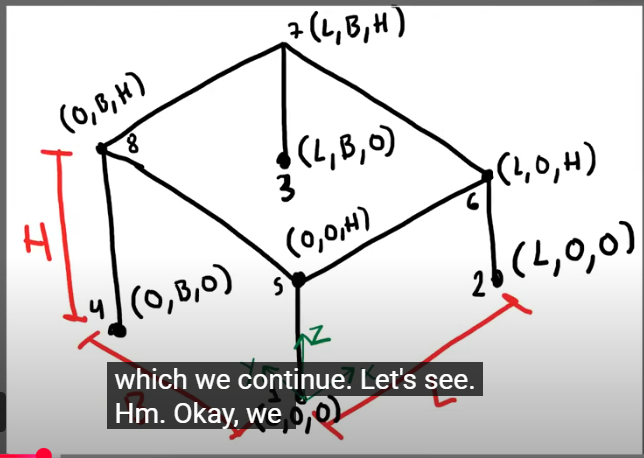
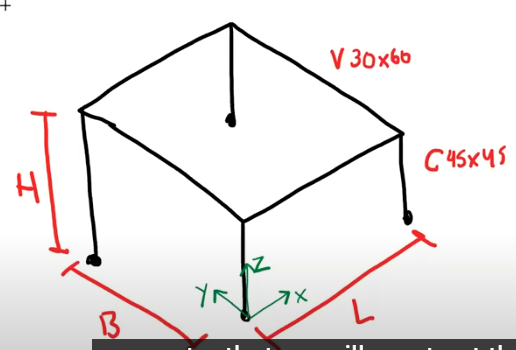

In [221]:
B = 3.2
L = 6.5
H = 2.7

E = 2.1e7
G = E / (2 * (1 + 0.2))

<Axes3D: xlabel='X', ylabel='Y', zlabel='Z'>

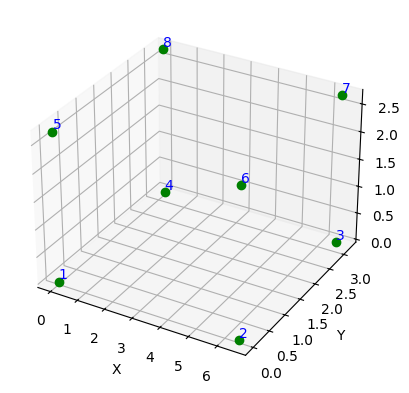

In [222]:
# Define nodes
ops.node(1, 0.0, 0.0, 0.0)
ops.node(2, L, 0.0, 0.0)    
ops.node(3, L, B, 0.0)
ops.node(4, 0.0, B, 0.0) 
ops.node(5, 0.0, 0.0, H)
ops.node(6, L, 0.0, H)
ops.node(7, L, B, H)
ops.node(8, 0.0, B, H)

opsv.plot_model()



In [223]:
# Columns
a = 0.45
A_col = a * a
Iz_col = (a ** 4) / 12
Iy_col = Iz_col
J_col = (2 * Iz_col)


In [224]:
# Beams
b, h = 0.3, 0.6
A_beam = b * h
Iz_beam = (h * b**3) / 12
Iy_beam = (b * h**3) / 12
J_beam = (b * h) * (b**2 + h**2) / 12

In [225]:
ops.geomTransf('Linear', 1, *[1, 0, 0])
ops.geomTransf('Linear', 2, *[0, 0, 1])

<Axes3D: xlabel='X', ylabel='Y', zlabel='Z'>

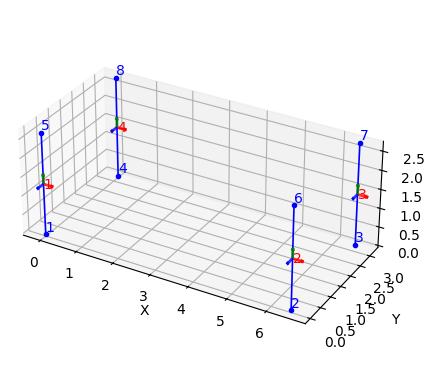

In [226]:
# Columns
ops.element('elasticBeamColumn', 1, 1, 5, A_col, E, G, J_col, Iy_col, Iz_col, 1)
ops.element('elasticBeamColumn', 2, 2, 6, A_col, E, G, J_col, Iy_col, Iz_col, 1)
ops.element('elasticBeamColumn', 3, 3, 7, A_col, E, G, J_col, Iy_col, Iz_col, 1)
ops.element('elasticBeamColumn', 4, 4, 8, A_col, E, G, J_col, Iy_col, Iz_col, 1)
opsv.plot_model()

<Axes3D: xlabel='X', ylabel='Y', zlabel='Z'>

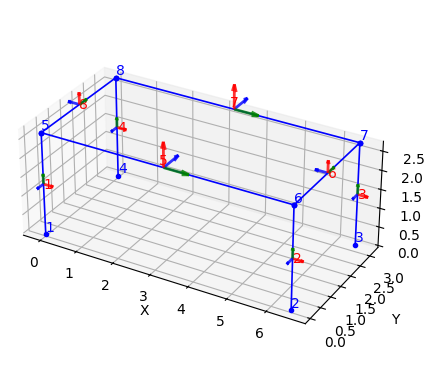

In [227]:
# Beams
ops.element('elasticBeamColumn', 5, 5, 6, A_beam, E, G, J_beam, Iy_beam, Iz_beam, 2)
ops.element('elasticBeamColumn', 6, 6, 7, A_beam, E, G, J_beam, Iy_beam, Iz_beam, 2)
ops.element('elasticBeamColumn', 7, 8, 7, A_beam, E, G, J_beam, Iy_beam, Iz_beam, 2)
ops.element('elasticBeamColumn', 8, 5, 8, A_beam, E, G, J_beam, Iy_beam, Iz_beam, 2)
opsv.plot_model()

<Axes3D: xlabel='X', ylabel='Y', zlabel='Z'>

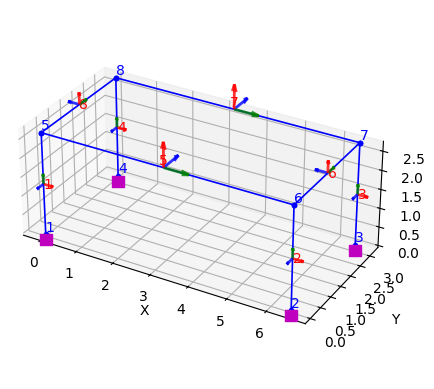

In [228]:
ops.fix(1, 1, 1, 1, 1, 1, 1)
ops.fix(2, 1, 1, 1, 1, 1, 1)
ops.fix(3, 1, 1, 1, 1, 1, 1)
ops.fix(4, 1, 1, 1, 1, 1, 1)
opsv.plot_model()

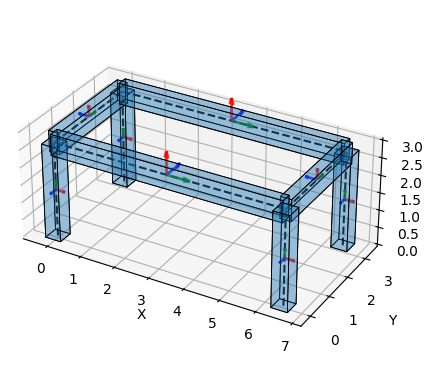

In [229]:
ele_shapes = {
    1: ['rect', [a, a]],
    2: ['rect', [a, a]],
    3: ['rect', [a, a]],
    4: ['rect', [a, a]],
    5: ['rect', [h, b]],
    6: ['rect', [h, b]],
    7: ['rect', [h, b]],
    8: ['rect', [h, b]]
}
opsv.plot_extruded_shapes_3d(ele_shapes)

In [230]:
# Loads

ops.timeSeries('Linear', 1)
ops.pattern('Plain', 1, 1)

q = 1.20  # kN/m
ops.eleLoad('-ele', 5, '-type', '-beamUniform', 0, -q, 0)
ops.eleLoad('-ele', 6, '-type', '-beamUniform', 0, -q, 0)
ops.eleLoad('-ele', 7, '-type', '-beamUniform', 0, -q, 0)
ops.eleLoad('-ele', 8, '-type', '-beamUniform', 0, -q, 0)

In [231]:
ops.load(5,0,10,0,0,0,0)
ops.load(6,0,10,0,0,0,0)

In [232]:
# Analysis configuration
ops.system('BandGeneral')
ops.constraints('Plain')
ops.numberer('RCM')
ops.test('NormDispIncr', 1e-6, 10)
ops.algorithm('Newton')
ops.integrator('LoadControl', 1.0)
ops.analysis('Static')  
ops.analyze(1)


0

(20000.0, <Axes3D: xlabel='X', ylabel='Y', zlabel='Z'>)

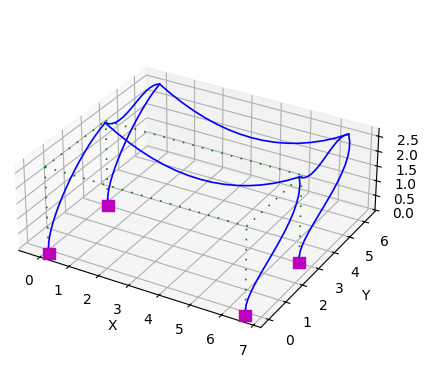

In [233]:
opsv.plot_defo(2e4)